# Ноутбук по отбору признаков

# Imports + Spark Initialization

In [1]:
import os
import sys

# ----------------COMMENT FOR DATALAB PRO----------------
os.environ['SPARK_MAJOR_VERSION'] = '3'
os.environ['SPARK_HOME'] = '/usr/sdp/current/spark3-client/'
os.environ['PYSPARK_PYTHON'] = '/data/sdp/mlpy3811v23/bin/python'
os.environ['PYSPARK_DRIVER_PYTHON'] = '/data/sdp/mlpy3811v23/bin/python'
os.environ['LD_LIBRARY_PATH'] = '/opt/python/virtualenv/jupyter/lib'
sys.path.insert(0, '/usr/sdp/current/spark3-client/python/')
sys.path.insert(0, '/usr/sdp/current/spark3-client/python/lib/py4j-0.10.9.3-src.zip')
sys.path.append('../')

In [2]:
import copy
import re
import json
import random

from datetime import datetime
from dateutil.relativedelta import relativedelta

import joblib

from IPython.display import clear_output
from tqdm import tqdm

# work with data
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, train_test_split

from lightgbm import LGBMClassifier

import pyspark
from pyspark.sql import SparkSession
from pyspark import SparkConf
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

from utils.get_spark import get_spark
from utils import show_results
from utils.feature_selection import *

%matplotlib inline

In [3]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [4]:
spark = get_spark(app_name='srs-bo-push-fs')
clear_output()

display(spark)

In [5]:
# # ----------------DATALAB PRO VERSION----------------
# # spark ui

# jlabUrl = os.environ['JLAB_URL']
# jlabNs = os.environ['JLAB_NS']
# sparkUiPort = spark.sparkContext.uiWebUrl.split(':')[2]
# print(jlabUrl + "/" + jlabNs + "/datalabpro/jserver/proxy/" + sparkUiPort + "/jobs/")

# Константы

In [6]:
PRODUCT = 'BO_PUSH'
PREFIX = 'srs'

DATASET_TABLE = f"{PREFIX}_{PRODUCT.lower()}_dataset"

target_column = 'target'
treatment_column = 'cg_flg'
date_column = 'report_dt'
technical_columns = set([
    'cltv_lag_3',
    'pl_val_lag_3',
    'residual_npv_val_lag_3', 
    'sale_dt',
    'start_dt',
    'target',
    'channel_name',
    'epk_id',
    'res_1',
    'id_target', 
    'ctl_loading',
    'row_upd_dttm', 
    'insert_time', 
    'ctl_validfrom', 
    'ctl_action',
    'insert_dttm', 
    'hash_val', 
    'row_upd_dt']
)

dates_not_to_include = ['2025-09-30', '2025-10-31']

In [7]:
target = spark.table("arnsdpsbx_t_team_mp_cmpn_ds.srs_bo_push_sms_target")
clear_output()

In [8]:
target.columns

['epk_id', 'cg_flg', 'start_dt', 'target', 'report_dt']

# Предобработка данных

In [9]:
dataset = spark.table(f'arnsdpsbx_t_team_mp_cmpn_ds.{DATASET_TABLE}')

dataset = dataset.withColumn(date_column, F.col(date_column).cast('string'))
dataset = dataset.withColumn('epk_id', F.col('epk_id').cast('string'))

dataset_columns = set(dataset.columns)
clear_output()

In [10]:
dates_target = dataset.select(['report_dt']).distinct().collect()
dates_target = sorted(row.report_dt for row in dates_target)
clear_output()
dates_target

['2025-01-31',
 '2025-02-28',
 '2025-03-31',
 '2025-04-30',
 '2025-05-31',
 '2025-06-30',
 '2025-07-31',
 '2025-08-31',
 '2025-09-30',
 '2025-10-31']

In [11]:
print(f'Report_dts not to include: {dates_not_to_include}')
dates_target = [date for date in dates_target if date not in dates_not_to_include]
print(f'Report dts: {dates_target}')

Report_dts not to include: ['2025-09-30', '2025-10-31']
Report dts: ['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31']


In [12]:
dataset = dataset.filter(F.col(date_column).isin(dates_target))

In [13]:
os.makedirs('./cache', exist_ok=True)
os.makedirs('./cache/feature_selection', exist_ok=True)

In [14]:
target_dist_pd = dataset.select(['epk_id', date_column, treatment_column, target_column]).toPandas()

In [15]:
target_dist_pd = target_dist_pd.dropna(subset='epk_id')

In [16]:
target_dist_pd.groupby(['report_dt', 'cg_flg'])['target'].mean()

report_dt   cg_flg
2025-01-31  0         0.004161
            1         0.001457
2025-02-28  0         0.002202
            1         0.001368
2025-03-31  0         0.001705
            1         0.001149
2025-04-30  0         0.003376
            1         0.002771
2025-05-31  0         0.004132
            1         0.002850
2025-06-30  0         0.005648
            1         0.003545
2025-07-31  0         0.005749
            1         0.003938
2025-08-31  0         0.003194
            1         0.002038
Name: target, dtype: float64

In [17]:
target_dist_pd.groupby('cg_flg')['target'].mean()

cg_flg
0    0.003725
1    0.002383
Name: target, dtype: float64

In [18]:
target_dist_pd[target_dist_pd[target_column].isna()].groupby(date_column, as_index=False)['epk_id'].count()

,report_dt,epk_id


In [19]:
for date in target_dist_pd['report_dt'].unique():
    print(date, target_dist_pd[target_dist_pd['report_dt'] == date].duplicated(subset=['epk_id']).sum())

2025-06-30 0
2025-08-31 0
2025-04-30 0
2025-02-28 0
2025-03-31 0
2025-07-31 0
2025-05-31 0
2025-01-31 0


## Фильтрация данных

### Удалим столбцы с большим числом пропусков

In [20]:
def remove_null_cols(df, thr: float=0.95):
    """
    Keep columns containing less than 'thr' percent of nulls
    """
    df_len = df.count()
    null_stats = df.select([(F.count(F.when(F.isnull(c), c)) / df_len).alias(c) for c in df.columns]).collect()
    null_stats = [row.asDict() for row in null_stats][0]
    columns = [col for col, per_null in null_stats.items() if per_null < thr]
    return df.select(columns), null_stats

In [21]:
dataset, null_stats = remove_null_cols(dataset)
print(len(dataset.columns), len(dataset_columns))

26/02/02 11:10:32 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/02/02 11:10:35 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/02/02 11:14:30 WARN DAGScheduler: Broadcasting large task binary with size 5.4 MiB


3124 3428


In [22]:
# set(dataset_columns) - set(dataset.columns)

In [23]:
len_dataset = dataset.count()
len_dataset

3240371

### Удалим сильно скоррелированные столбцы

In [24]:
def find_correlated_columns(subset: pd.DataFrame, thr: float=0.95):
    corrs = subset.corr(numeric_only=True)
    columns = corrs.columns
    n = len(columns)
    
    correlated_columns = []
    correlated_columns_pairs = {}
    
    for i in range(n):
        if columns[i] in correlated_columns:  # если мы уже удалили эту колонку, то не смотрим на ее корреляции
            continue
        for j in range(i+1, n):
            val = corrs.iloc[i, j]  # смотрим на корреляцию
            
            if abs(val) > thr:  # положительная и отрицательная корреляция
                correlated_columns_pairs[(columns[i], columns[j])] = val
                correlated_columns.append(columns[j])
    return set(correlated_columns), correlated_columns_pairs

### Предобработаем decimal

In [20]:
# найдем признаки с типом decimal и приведем их к числовому типу
decimal_columns = list(filter(lambda x: 'decimal' in x[1], dataset.dtypes))
decimal_columns = [col[0] for col in decimal_columns]
print(len(decimal_columns))

for col_name in decimal_columns:
    dataset = dataset.withColumn(col_name, F.col(col_name).cast('float'))
    
set(map(lambda x: x[1], dataset.dtypes))  # какие уникальные типы данных присутствуют в датасете

436


{'bigint', 'double', 'float', 'int', 'string', 'timestamp', 'tinyint'}

In [25]:
columns_to_check = []

for col_name, dtype in dataset.dtypes:
    if dtype not in ('string', 'timestamp'):
        columns_to_check.append(col_name)
        
columns_to_check = list(set(columns_to_check) - technical_columns - set([target_column, treatment_column, date_column]))

In [27]:
if len_dataset < 200000:
    check_corr_dataset = dataset.select(columns_to_check).toPandas()
    
else:
    fraction = np.round(200000 / len_dataset, 2)
    print(f'Correlation sample fraction: {fraction}')

    check_corr_dataset = dataset.select(columns_to_check).sample(fraction=fraction, withReplacement=False, seed=SEED).toPandas()

0.06


26/01/28 15:22:08 WARN DAGScheduler: Broadcasting large task binary with size 1023.9 KiB


In [28]:
print(f'Check correlation dataset shape: {check_corr_dataset.shape}')

(194672, 2972)

In [29]:
correlated_columns, corr_stats = find_correlated_columns(check_corr_dataset)

In [30]:
print(f'Length of correlated columns: {len(correlated_columns)}')

424

In [31]:
features = set(dataset.columns) - technical_columns - set([target_column, treatment_column]) - set([date_column]) - correlated_columns

In [32]:
joblib.dump(features, './cache/feature_selection/features_after_base_prep.pkl')
joblib.dump(corr_stats, './cache/feature_selection/corr_stats.pkl')

['./cache/feature_selection/corr_stats.pkl']

## Подготовка подмножества для отбора признаков

In [21]:
features = joblib.load('./cache/feature_selection/features_after_base_prep.pkl')

dataset = dataset.select(list(features)+[target_column, treatment_column, date_column])

### Найдем временные признаки

In [22]:
def find_dt_features(sdf):
    def find_dt(col):
        res = re.search(r'.*(_dt).*', col)
        if res is not None:
            result = res.group(0)
            if result != date_column:
                return result
        
    return list(filter(find_dt, sdf.columns))

dt_features = find_dt_features(dataset)

In [23]:
def count_dt_diff(sdf, dt_features, date_col):
    """Для временных признаков посчитаем их разницу с report_dt"""
    for col in dt_features:
        sdf = sdf.withColumn(col+'_diff', F.datediff(F.col(date_column), F.col(col))).drop(col)
    return sdf

# для признаков с типом дата, посчитаем разницу в днях между date_column и этим признаком

dataset = count_dt_diff(dataset, dt_features, date_column)

### Найдем все битовые маски

In [24]:
bitmask_cols = list(filter(lambda x: 'bitmask' in x, dataset.columns))
bitmask_cols

['dep_social_bitmask_l12m_cd', 'dep_payroll_bitmask_l12m_cd']

In [25]:
# для побитовых признаков посчитаем сумму

@F.udf(returnType=IntegerType())
def count_ones(col):
    if isinstance(col, str):  # бывает Null
        events = list(col)
        s = 0
        for e in events:
            if e.isdigit():  # встречаются символы X
                s += int(e)
        return s
    
def count_payroll(sdf, bitmask_features):
    """Для побитовых масок посчитаем сумму"""
    for col in bitmask_features:
        sdf = sdf.withColumn(col+'_sum', count_ones(col)).drop(col)
    return sdf

In [26]:
dataset = count_payroll(dataset, bitmask_cols)

### Найдем все строковые колонки

In [27]:
def find_string_features(sdf):
    def find_str(pair):
        col, dtype = pair
        if col not in [target_column, date_column]:
            if dtype == 'string':
                return col
    
    return [pair[0] for pair in list(filter(find_str, sdf.dtypes))]

string_features = find_string_features(dataset)
len(string_features)

54

### Заполним пропуски

In [28]:
dataset.filter(F.isnull(target_column)).count()

0

In [30]:
# dataset.filter(F.col(target_column) == 0).count()

In [31]:
# dataset = dataset.fillna(0, subset=[target_column])  # target
dataset = dataset.dropna(subset=[target_column])  # target

In [32]:
dataset.filter(F.isnull(target_column)).count()

0

In [33]:
dataset = dataset.fillna(-999999)  # числовые
dataset = dataset.fillna('')  # строковые

In [34]:
len_dataset = dataset.count()
len_dataset

3240371

# Отбор признаков

### Sample данных

In [35]:
if len_dataset < 700000:
    dataset_pd_sample = dataset.toPandas()
    
else:
    print('Sampling')
    fraction = np.round(700000 / len_dataset, 2)
    print(f'Sample fraction: {fraction}')

    # random sampling
#     dataset_pd_sample = dataset.sample(fraction=fraction, withReplacement=False, seed=SEED).toPandas()

    # stratified sampling
    dataset = dataset.withColumn('stratification_col', F.concat(
        F.col(target_column).cast('string'),
        F.lit('_'),
        F.col(treatment_column).cast('string'),
        F.lit('_'),
        F.col(date_column).cast('string')
    ))
    strat_count = dataset.groupBy("stratification_col").count().collect()
    strat_count = {row['stratification_col']: row['count'] / len_dataset for row in strat_count}
    
    print(f"Stratification stats:\n{strat_count}")
    print("ATE")
    dataset.groupby(treatment_column).agg(F.mean(target_column)).show()
    
    fractions = {key: fraction for key in strat_count.keys()}
    
    dataset_pd_sample = dataset.sampleBy(col='stratification_col', fractions=fractions, seed=SEED).toPandas()
    
    print(f"Sample stratification stats:\n{dataset_pd_sample['stratification_col'].value_counts(normalize=True)}")
    dataset_pd_sample.drop(['stratification_col'], axis=1, inplace=True)
    
    print(f"Sample ATE:\n{dataset_pd_sample.groupby(treatment_column)[target_column].mean()}")

Sampling
Sample fraction: 0.22


Stratification stats:
{'0_0_2025-04-30': 0.06522709899576314, '0_0_2025-02-28': 0.06587393850889296, '0_1_2025-03-31': 0.06571438887707612, '1_0_2025-06-30': 0.0003684763257046801, '0_0_2025-06-30': 0.06486973250902443, '1_1_2025-04-30': 0.0001814607031108475, '1_0_2025-04-30': 0.00022096235276763062, '1_1_2025-08-31': 0.0001391815937125718, '0_0_2025-08-31': 0.06781322262173066, '0_1_2025-04-30': 0.0653067195083526, '0_1_2025-08-31': 0.06816997189519348, '1_0_2025-02-28': 0.00014535372647144417, '0_0_2025-03-31': 0.0657631487258712, '0_1_2025-02-28': 0.06601065124950199, '1_1_2025-06-30': 0.00023083776518182642, '0_1_2025-06-30': 0.06488022513471452, '1_1_2025-02-28': 9.042174491748012e-05, '1_1_2025-03-31': 7.560862629618646e-05, '1_0_2025-08-31': 0.0002172590731123072, '1_0_2025-03-31': 0.00011233281621147702, '0_1_2025-07-31': 0.05971538444209012, '0_0_2025-07-31': 0.05956571022268747, '1_0_2025-07-31': 0.0003444050079450779, '1_1_2025-07-31': 0.0002360840780268679, '0_0_2025-05-31

+------+--------------------+
|cg_flg|         avg(target)|
+------+--------------------+
|     1|0.002383038590169...|
|     0|0.003725263944890295|
+------+--------------------+



26/03/06 15:38:34 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/06 15:38:35 WARN DAGScheduler: Broadcasting large task binary with size 1130.3 KiB


Sample stratification stats:
stratification_col
0_0_2025-08-31    0.068070
0_1_2025-08-31    0.067759
0_1_2025-02-28    0.066022
0_0_2025-03-31    0.065969
0_0_2025-02-28    0.065787
0_1_2025-03-31    0.065448
0_0_2025-04-30    0.065410
0_1_2025-04-30    0.064851
0_1_2025-06-30    0.064741
0_0_2025-06-30    0.064597
0_1_2025-07-31    0.060017
0_0_2025-07-31    0.059670
0_0_2025-05-31    0.057151
0_1_2025-05-31    0.056335
0_1_2025-01-31    0.052634
0_0_2025-01-31    0.052458
1_0_2025-06-30    0.000391
1_0_2025-07-31    0.000334
1_0_2025-05-31    0.000249
1_1_2025-06-30    0.000233
1_1_2025-07-31    0.000230
1_0_2025-01-31    0.000229
1_0_2025-08-31    0.000216
1_0_2025-04-30    0.000211
1_1_2025-04-30    0.000185
1_1_2025-05-31    0.000171
1_1_2025-08-31    0.000141
1_0_2025-02-28    0.000135
1_0_2025-03-31    0.000108
1_1_2025-02-28    0.000086
1_1_2025-01-31    0.000084
1_1_2025-03-31    0.000079
Name: proportion, dtype: float64
Sample ATE:
cg_flg
0    0.003737
1    0.002424
Name: ta

In [36]:
dataset_pd_sample.shape

(742454, 2696)

In [37]:
dataset_pd_sample.reset_index().groupby(['cg_flg'])['target'].value_counts(normalize=True)

cg_flg  target
0       0         0.996263
        1         0.003737
1       0         0.997576
        1         0.002424
Name: proportion, dtype: float64

In [38]:
dataset_pd_sample['cg_flg'].value_counts(normalize=True)

cg_flg
0    0.500985
1    0.499015
Name: proportion, dtype: float64

In [39]:
for col in string_features:
    dataset_pd_sample[col] = dataset_pd_sample[col].astype('category')
    
dataset_pd_sample_prep = dataset_pd_sample.copy()

# кодируем категории
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
dataset_pd_sample_prep[string_features] = enc.fit_transform(dataset_pd_sample_prep[string_features], dataset_pd_sample_prep[target_column])

dataset_pd_sample_prep.dtypes.unique()

array([dtype('float32'), dtype('int32'), dtype('int64'), dtype('float64'),
       dtype('int8'), dtype('O')], dtype=object)

In [40]:
# меняем столбец с treatment
dataset_pd_sample_prep['is_treated'] = dataset_pd_sample_prep[treatment_column].map({1: 0, 0: 1})

# меняем имена признаков, так как мы их подготовили выше
prep_features = []
for feat in features:
    if feat in dt_features:
        prep_features.append(feat+'_diff')
    elif feat in bitmask_cols:
        prep_features.append(feat+'_sum')
    else:
        prep_features.append(feat)
        
dataset_pd_sample_prep = dataset_pd_sample_prep[prep_features+['is_treated', target_column, date_column]]

### Проверим качество модели на всех признаках

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from catboost import CatBoostClassifier

from category_encoders import TargetEncoder

Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


In [42]:
dataset_pd_sample_prep.head()

,crd_dc_pos_auto_rub_amt,sbol_category_map_4,srv_mb_tot_qty,embedding_185,srv_ap_utl_nflag,site_open_cnt,offers_cm_p_strtd_cnt,sbol_category_map_411,srv_sbol_mnth_atm_lst_log_qty,crd_dc_open_qty,...,seq_hidden_state_4,srv_sbol_1st_login_dt_diff,prl_tax_payer_inn,sbol_category_map_119,embedding_34,cc_dlvrd_cnt,sbol_category_map_171,is_treated,target,report_dt
0,-999999.000000,0,1,0.095141,0,0,0,106,70.774194,1,...,-171.362244,29,0.0,0,0.044038,0,0,0,0,2025-06-30
1,6189.759766,0,1,0.479667,0,0,0,57,23.451613,2,...,239.981628,29,0.0,0,0.281182,0,0,1,0,2025-06-30
2,-999999.000000,0,1,-0.136870,0,0,0,30,-999999.000000,2,...,85.485825,29,0.0,0,0.243863,0,0,0,0,2025-06-30
3,-999999.000000,0,1,0.303262,0,0,0,95,20.290323,2,...,239.862488,28,0.0,0,0.375174,0,0,1,0,2025-06-30
4,2059.750000,0,1,0.148094,0,0,0,48,-999999.000000,2,...,124.196999,28,0.0,0,0.396579,0,0,1,0,2025-06-30


In [43]:
train_dataset = dataset_pd_sample_prep

train, val = train_test_split(train_dataset, test_size=0.2, shuffle=True, stratify=train_dataset[['is_treated', 'target']], random_state=SEED)

In [44]:
# # добавим таргет энкодер
# enc = TargetEncoder(cols=string_features)
# enc.fit(train[string_features], train[target_column])

# train[string_features] = enc.transform(train[string_features])
# val[string_features] = enc.transform(val[string_features])

In [45]:
train.groupby('is_treated').agg({'target': 'mean'})

,target
is_treated,
0,0.002426
1,0.003737


In [46]:
val.groupby('is_treated').agg({'target': 'mean'})

,target
is_treated,
0,0.002416
1,0.003737


In [90]:
with open('./cache/feature_selection/summary_catboost_c.txt', 'r') as f:
    summary_c = json.load(f)
    
with open('./cache/feature_selection/summary_catboost_tr.txt', 'r') as f:
    summary_tr = json.load(f)
    
features = list(set(summary_c['eliminated_features_names']) 
                | set(summary_c['selected_features_names']) | set(summary_tr['eliminated_features_names']) | set(summary_tr['selected_features_names']))

In [106]:
model = CatBoostClassifier(iterations=700, verbose=100, random_state=SEED)

model.fit(train.drop(['target', 'report_dt'], axis=1), train['target'])
# model.fit(train[features+['is_treated']], train['target'])
# model.fit(train[selected_all+['is_treated']], train['target'])

Learning rate set to 0.218461
0:	learn: 0.2518743	total: 373ms	remaining: 4m 20s
100:	learn: 0.0179191	total: 27.1s	remaining: 2m 40s
200:	learn: 0.0169379	total: 53.2s	remaining: 2m 12s
300:	learn: 0.0161756	total: 1m 18s	remaining: 1m 44s
400:	learn: 0.0154838	total: 1m 45s	remaining: 1m 18s
500:	learn: 0.0148585	total: 2m 16s	remaining: 54s
600:	learn: 0.0142318	total: 2m 47s	remaining: 27.7s
699:	learn: 0.0136833	total: 3m 20s	remaining: 0us


In [107]:
preds = model.predict_proba(val.drop(['target', 'report_dt'], axis=1))[:, 1]
# preds = model.predict_proba(val[features+['is_treated']])[:, 1]
# preds = model.predict_proba(val[selected_all+['is_treated']])[:, 1]

In [108]:
roc_auc_score(val['target'], preds)

0.8250263726450683

In [109]:
print(classification_report(val['target'], (preds >= 0.1).astype(int)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    148034
           1       0.08      0.01      0.02       457

    accuracy                           1.00    148491
   macro avg       0.54      0.51      0.51    148491
weighted avg       0.99      1.00      1.00    148491



In [110]:
model.get_feature_importance(prettified=True).head(50)

,Feature Id,Importances
0,sd_gender_cd,5.111833
1,seq_hidden_state_84,4.302260
2,sd_age_mnth_comp_nv_sum_3mnth,3.593234
3,tag_11491,1.904465
4,seq_hidden_state_96,1.861819
5,embedding_240,1.834446
6,seg_name_age_cd,1.802840
7,is_treated,1.757576
8,dep_acct_dep_save_bal_rub_amt,1.735106
9,tag_14474,1.516331


In [111]:
imps = model.get_feature_importance(prettified=True)
imps[imps['Importances'] != 0].shape[0]

1235

In [112]:
uplift_val = (model.predict_proba(val.drop(['target', 'report_dt'], axis=1).assign(is_treated=np.ones(shape=(val.shape[0], 1))))[:, 1] - 
              model.predict_proba(val.drop(['target', 'report_dt'], axis=1).assign(is_treated=np.zeros(shape=(val.shape[0], 1))))[:, 1])

# uplift_val = (model.predict_proba(val[features].assign(is_treated=np.ones(shape=(val.shape[0], 1))))[:, 1] - 
#               model.predict_proba(val[features].assign(is_treated=np.zeros(shape=(val.shape[0], 1))))[:, 1])

# uplift_val = (model.predict_proba(val[selected_all].assign(is_treated=np.ones(shape=(val.shape[0], 1))))[:, 1] - 
#               model.predict_proba(val[selected_all].assign(is_treated=np.zeros(shape=(val.shape[0], 1))))[:, 1])

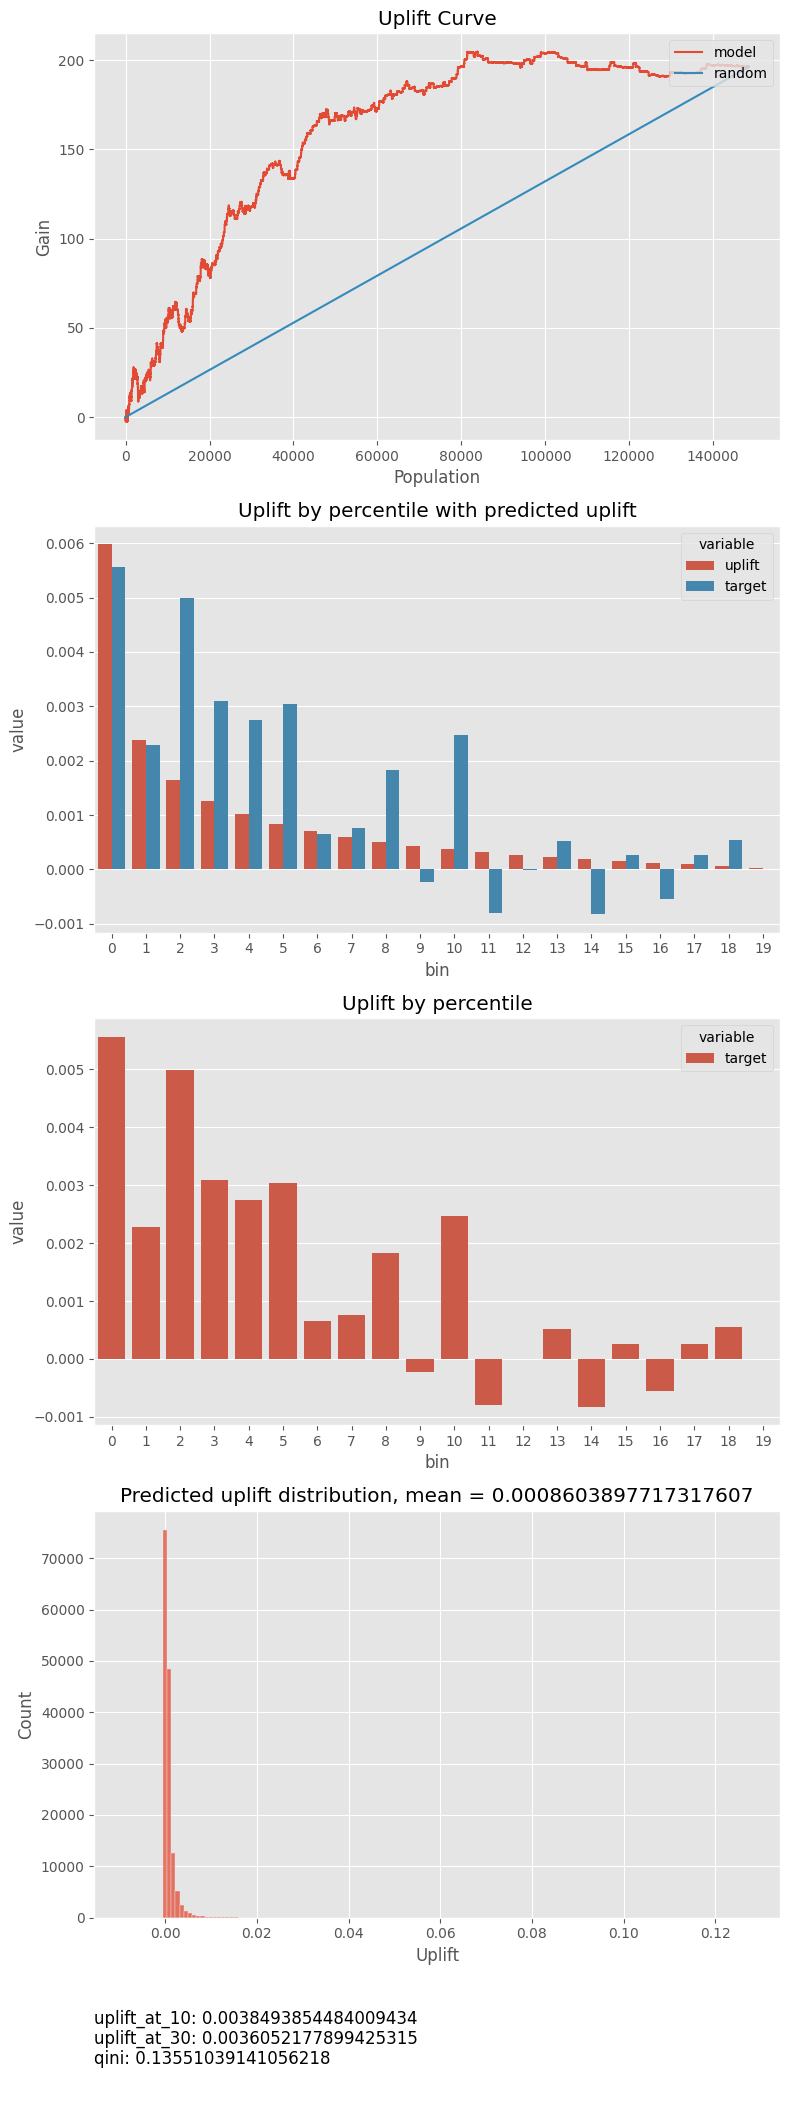

,uplift_at_10,uplift_at_30,qini
0,0.003849,0.003605,0.13551


In [113]:
show_results(val[target_column].values.ravel(), uplift_val, val['is_treated'].values.ravel(), save=False, save_prefix='all_features')

# show_results(val[target_column].values.ravel(), uplift_val, val['is_treated'].values.ravel(), save=False, save_prefix='first_step_features')

# show_results(val[target_column].values.ravel(), uplift_val, val['is_treated'].values.ravel(), save=True, save_prefix='selected_features')

In [116]:
del train_dataset, train, val

In [118]:
del model, preds, uplift_val

In [119]:
import gc
gc.collect()

42

### Классический отбор признаков с использованием LightGBM Feature Importances и SHAP, отдельно для контрольной и целевой групп с объединением результатов

#### Treatment

In [11]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1].drop([target_column, date_column, 'is_treated'], axis=1)
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1][target_column]

In [12]:
lgm_fs_treatment = LGMFeatureSelection(random_state=SEED)

lgm_fs_treatment.fit(x=x.values, y=y.values, columns=x.columns.tolist())
lgm_fs_treatment.importances.to_csv('./cache/feature_selection/lgm_fs_treatment_imps.csv', index=False)
lgm_fs_treatment.importances = pd.read_csv('./cache/feature_selection/lgm_fs_treatment_imps.csv')

FOLD: 0
FOLD: 1
FOLD: 2
FOLD: 3
FOLD: 4


In [13]:
shap_fs_treatment = ShapFeatureSelection(random_state=SEED)

shap_fs_treatment.fit(x=x.values, y=y.values, columns=x.columns.tolist())
shap_fs_treatment.importances.to_csv('./cache/feature_selection/shap_fs_treatment_imps.csv', index=False)
shap_fs_treatment.importances = pd.read_csv('./cache/feature_selection/shap_fs_treatment_imps.csv')

FOLD: 0


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 1


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 2


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 3


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 4


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


#### Control

In [14]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0].drop([target_column, date_column, 'is_treated'], axis=1)
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0][target_column]

In [15]:
lgm_fs_control = LGMFeatureSelection(random_state=SEED)

lgm_fs_control.fit(x=x.values, y=y.values, columns=x.columns.tolist())
lgm_fs_control.importances.to_csv('./cache/feature_selection/lgm_fs_control_imps.csv', index=False)
lgm_fs_control.importances = pd.read_csv('./cache/feature_selection/lgm_fs_control_imps.csv')

FOLD: 0
FOLD: 1
FOLD: 2
FOLD: 3
FOLD: 4


In [16]:
shap_fs_control = ShapFeatureSelection(random_state=SEED)

shap_fs_control.fit(x=x.values, y=y.values, columns=x.columns.tolist())
shap_fs_control.importances.to_csv('./cache/feature_selection/shap_fs_control_imps.csv', index=False)
shap_fs_control.importances = pd.read_csv('./cache/feature_selection/shap_fs_control_imps.csv')

FOLD: 0


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 1


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 2


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 3


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


FOLD: 4


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


#### Объединение

In [17]:
selected = list((set(shap_fs_control.get_selected_features(0.85)) & set(lgm_fs_control.get_selected_features(0.85))) \
     | (set(shap_fs_treatment.get_selected_features(0.85)) & set(lgm_fs_treatment.get_selected_features(0.85))))

In [18]:
len(selected)

215

In [20]:
joblib.dump(selected, './cache/feature_selection/selected_2_models_first_step.pkl')

['./cache/feature_selection/selected_2_models_first_step.pkl']

### Stability Check

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, CatBoostError

def check_feature_stability(df, date_column, dates, features_list):
    results = {}
    combs = []

    for i, first_date in enumerate(dates):
        for second_date in dates[i+1:]:
            print(f"FIRST_DATE: {first_date}, SECOND_DATE: {second_date}")
            combs.append((first_date, second_date))

            for feature in tqdm(features_list, position=0):
                if feature not in results.keys():
                    results[feature] = []

                check_df = df[df[date_column].isin([first_date, second_date])][[date_column, feature]].copy()
                check_df['target'] = (check_df[date_column] == second_date).astype(int)

                x_train, x_test, y_train, y_test = train_test_split(check_df[[feature]], check_df['target'], test_size=0.33, random_state=SEED)
                try:
                    estimator=CatBoostClassifier(n_estimators=500, max_depth=5, eval_fraction=0.2, od_wait=15, random_state=SEED, verbose=False)

                    estimator.fit(x_train, y_train)

                    preds = estimator.predict_proba(x_test)[:, 1]

                    score = roc_auc_score(y_test, preds)
                    results[feature].append(score)
                except CatBoostError as e:
                    print(f"Feature: {feature}\n{e}")
                    results[feature].append(0.5)
    return results, combs

In [31]:
dates = sorted(dataset_pd_sample_prep[date_column].unique())

stability_results, stability_combs = check_feature_stability(dataset_pd_sample_prep, date_column, dates, selected)

joblib.dump(stability_results, './cache/feature_selection/feature_stability_results.pkl')
joblib.dump(stability_combs, './cache/feature_selection/feature_stability_combs.pkl')

FIRST_DATE: 2025-01-31, SECOND_DATE: 2025-02-28


 13%|█▎        | 29/215 [01:05<07:04,  2.28s/it]

Feature: prl_client_app_income_amt_sum_12mnth
catboost/libs/data/quantization.cpp:2420: All features are either constant or ignored.


100%|██████████| 215/215 [08:24<00:00,  2.35s/it]


FIRST_DATE: 2025-01-31, SECOND_DATE: 2025-03-31


...

FIRST_DATE: 2025-06-30, SECOND_DATE: 2025-08-31


100%|██████████| 215/215 [09:14<00:00,  2.58s/it]


FIRST_DATE: 2025-07-31, SECOND_DATE: 2025-08-31


100%|██████████| 215/215 [09:48<00:00,  2.74s/it]


['./cache/feature_selection/feature_stability_combs.pkl']

In [32]:
dates

['2025-01-31',
 '2025-02-28',
 '2025-03-31',
 '2025-04-30',
 '2025-05-31',
 '2025-06-30',
 '2025-07-31',
 '2025-08-31']

In [33]:
stability_results = joblib.load('./cache/feature_selection/feature_stability_results.pkl')

stability_results = pd.DataFrame(stability_results)
mean_results = stability_results.mean()
selected = mean_results[mean_results < 0.6].index.tolist()

In [34]:
mean_results[mean_results < 0.6]

embedding_89            0.515992
embedding_83            0.590153
seq_hidden_state_32     0.526139
seq_hidden_state_202    0.537115
seq_hidden_state_193    0.519323
                          ...   
embedding_145           0.550905
seq_hidden_state_96     0.522190
seq_hidden_state_107    0.533862
embedding_90            0.541463
seq_hidden_state_44     0.537549
Length: 195, dtype: float64

In [35]:
mean_results[mean_results > 0.6]

res_26_sum_6mnth                        0.612534
crd_dc_lst_crd_1st_spnd_dt_diff         0.798266
sbol_category_map_489                   0.609957
prl_client_app_income_amt_sum_12mnth    0.617891
sbol_category_map_120                   0.607396
srv_sbol_mnth_1st_txn_qty               0.972089
sbol_category_map_550                   0.679094
embedding_126                           0.669902
tag_33318                               0.715086
embedding_40                            0.642431
sbol_category_map_436                   0.615773
cla_mb_active_last_dt_diff              0.690991
cla_curr_acc_active_last_dt_diff        0.726104
pnl_oi_ca_amt                           0.786142
embedding_37                            0.622053
tag_40648                               0.622478
embedding_142                           0.642625
embedding_255                           0.652212
embedding_91                            0.627925
embedding_72                            0.616203
dtype: float64

In [36]:
len(selected)

195

In [37]:
joblib.dump(selected, './cache/feature_selection/selected_2_models_first_step_stability.pkl')

['./cache/feature_selection/selected_2_models_first_step_stability.pkl']

In [46]:
selected = joblib.load('./cache/feature_selection/selected_2_models_first_step_stability.pkl')
len(selected)

195

### BorutaShap

In [47]:
from BorutaShap import BorutaShap

#### Treatment

In [40]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1][selected]
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1][target_column]

In [41]:
model = LGBMClassifier(max_depth=5, n_estimators=500, learning_rate=0.05, verbose=-100, random_state=SEED)

boruta_fs = BorutaShap(model=model, importance_measure='shap', classification=True)
boruta_fs.fit(X=x, y=y, n_trials=50, random_state=SEED)

  0%|          | 0/50 [00:00<?, ?it/s]

26 attributes confirmed important: ['srv_thanks_dt_diff', 'embedding_180', 'sd_gender_cd', 'seq_hidden_state_175', 'seq_hidden_state_41', 'embedding_244', 'prd_yrs_lst_open_qty', 'sd_age_mnth_comp_nv_sum_3mnth', 'seq_hidden_state_84', 'sbol_category_map_11', 'embedding_240', 'seq_hidden_state_177', 'seq_hidden_state_227', 'sbol_category_map_0', 'seq_hidden_state_50', 'seq_hidden_state_51', 'dep_acct_dc_bal_rub_amt_sum_3mnth', 'dep_acct_dep_max_open_dt_diff', 'dep_acct_tot_qty', 'seq_hidden_state_218', 'lne_pl_max_psb_trm_mnth_qty', 'srv_pmt_all_amt', 'embedding_207', 'seq_hidden_state_96', 'tag_11491', 'seq_hidden_state_212']
166 attributes confirmed unimportant: ['embedding_89', 'seq_hidden_state_32', 'embedding_83', 'seq_hidden_state_202', 'seq_hidden_state_193', 'pl_val_lag_7', 'pnl_oi_dc_amt_sum_3mnth', 'seq_hidden_state_93', 'prd_ma_active_qty', 'seq_hidden_state_166', 'seq_hidden_state_46', 'seq_hidden_state_133', 'embedding_36', 'embedding_31', 'embedding_161', 'seq_hidden_state

In [42]:
joblib.dump(boruta_fs, './cache/feature_selection/boruta_fs_tr.pkl')

['./cache/feature_selection/boruta_fs_tr.pkl']

In [48]:
boruta_fs_tr = joblib.load('./cache/feature_selection/boruta_fs_tr.pkl')
boruta_fs_tr.TentativeRoughFix()

selected_tr = list(set(boruta_fs_tr.accepted))
len(selected_tr)

0 tentative features are now accepted: []
3 tentative features are now rejected: ['sbol_category_map_284' 'seq_hidden_state_25' 'seq_hidden_state_40']


26

#### Control

In [49]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0][selected]
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0][target_column]

In [50]:
model = LGBMClassifier(max_depth=5, n_estimators=500, learning_rate=0.05, verbose=-100, random_state=SEED)

boruta_fs = BorutaShap(model=model, importance_measure='shap', classification=True)
boruta_fs.fit(X=x, y=y, n_trials=50, random_state=SEED)

  0%|          | 0/50 [00:00<?, ?it/s]

16 attributes confirmed important: ['dep_acct_dep_max_open_dt_diff', 'seq_hidden_state_96', 'prd_lst_prod_open_dt_diff', 'sbol_category_map_11', 'embedding_102', 'embedding_240', 'embedding_49', 'tag_11491', 'dep_acct_dep_save_bal_rub_amt', 'embedding_90', 'seq_hidden_state_24', 'tag_25978', 'seq_hidden_state_84', 'sbol_section_map_0', 'lne_pl_max_psb_trm_mnth_qty', 'embedding_19']
173 attributes confirmed unimportant: ['seq_hidden_state_226', 'embedding_148', 'seq_hidden_state_4', 'embedding_141', 'embedding_89', 'seq_hidden_state_129', 'embedding_156', 'tag_15819', 'seq_hidden_state_22', 'dep_acct_tot_qty', 'seq_hidden_state_31', 'embedding_204', 'embedding_86', 'seq_hidden_state_163', 'seq_hidden_state_65', 'seq_hidden_state_26', 'appl_mort_rej_sum_12mnth', 'embedding_160', 'embedding_105', 'seq_hidden_state_249', 'embedding_101', 'sbol_category_map_604', 'sbol_category_map_523', 'embedding_108', 'seq_hidden_state_62', 'seq_hidden_state_243', 'seq_hidden_state_248', 'seq_hidden_stat

In [51]:
joblib.dump(boruta_fs, './cache/feature_selection/boruta_fs_c.pkl')

['./cache/feature_selection/boruta_fs_c.pkl']

In [52]:
boruta_fs_c = joblib.load('./cache/feature_selection/boruta_fs_c.pkl')
boruta_fs_c.TentativeRoughFix()

selected_c = list(set(boruta_fs_c.accepted))
len(selected_c)

0 tentative features are now accepted: []
6 tentative features are now rejected: ['embedding_177' 'sd_age_mnth_comp_nv_sum_3mnth' 'embedding_130'
 'seq_hidden_state_107' 'seq_hidden_state_3' 'seq_hidden_state_155']


16

### Рекурсивный отбор

In [53]:
from catboost import CatBoostClassifier, EShapCalcType, EFeaturesSelectionAlgorithm

def select_features_catboost(x_train, y_train, x_val, y_val, num_features_to_select, steps):
    cb = CatBoostClassifier(iterations=1000, random_state=SEED)
    summary = cb.select_features(
        x_train,
        y_train,
        eval_set=(x_val, y_val),
        features_for_select=x_train.columns.tolist(),
        num_features_to_select=num_features_to_select,
        steps=steps,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level='Silent',
        plot=False
    )
    return summary

#### Treatment

In [54]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1][selected_tr]
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 1][target_column]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=SEED)

num_features_to_select = 1  # посмотрим на динамику ухудшения метрик
summary_tr = select_features_catboost(x_train, y_train, x_val, y_val, num_features_to_select=num_features_to_select, steps=x_train.shape[1]-num_features_to_select)

with open('./cache/feature_selection/summary_catboost_tr.txt', 'w') as f:
    json.dump(summary_tr, f)

#### Control

In [55]:
x = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0][selected_c]
y = dataset_pd_sample_prep[dataset_pd_sample_prep['is_treated'] == 0][target_column]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=SEED)

num_features_to_select = 1  # посмотрим на динамику ухудшения метрик
summary_c = select_features_catboost(x_train, y_train, x_val, y_val, num_features_to_select=num_features_to_select, steps=x_train.shape[1]-num_features_to_select)

with open('./cache/feature_selection/summary_catboost_c.txt', 'w') as f:
    json.dump(summary_c, f)

#### Selection

##### Treatment

In [5]:
with open('./cache/feature_selection/summary_catboost_tr.txt', 'r') as f:
    summary_tr = json.load(f)

In [6]:
summary_tr['selected_features_names']

['seq_hidden_state_84']

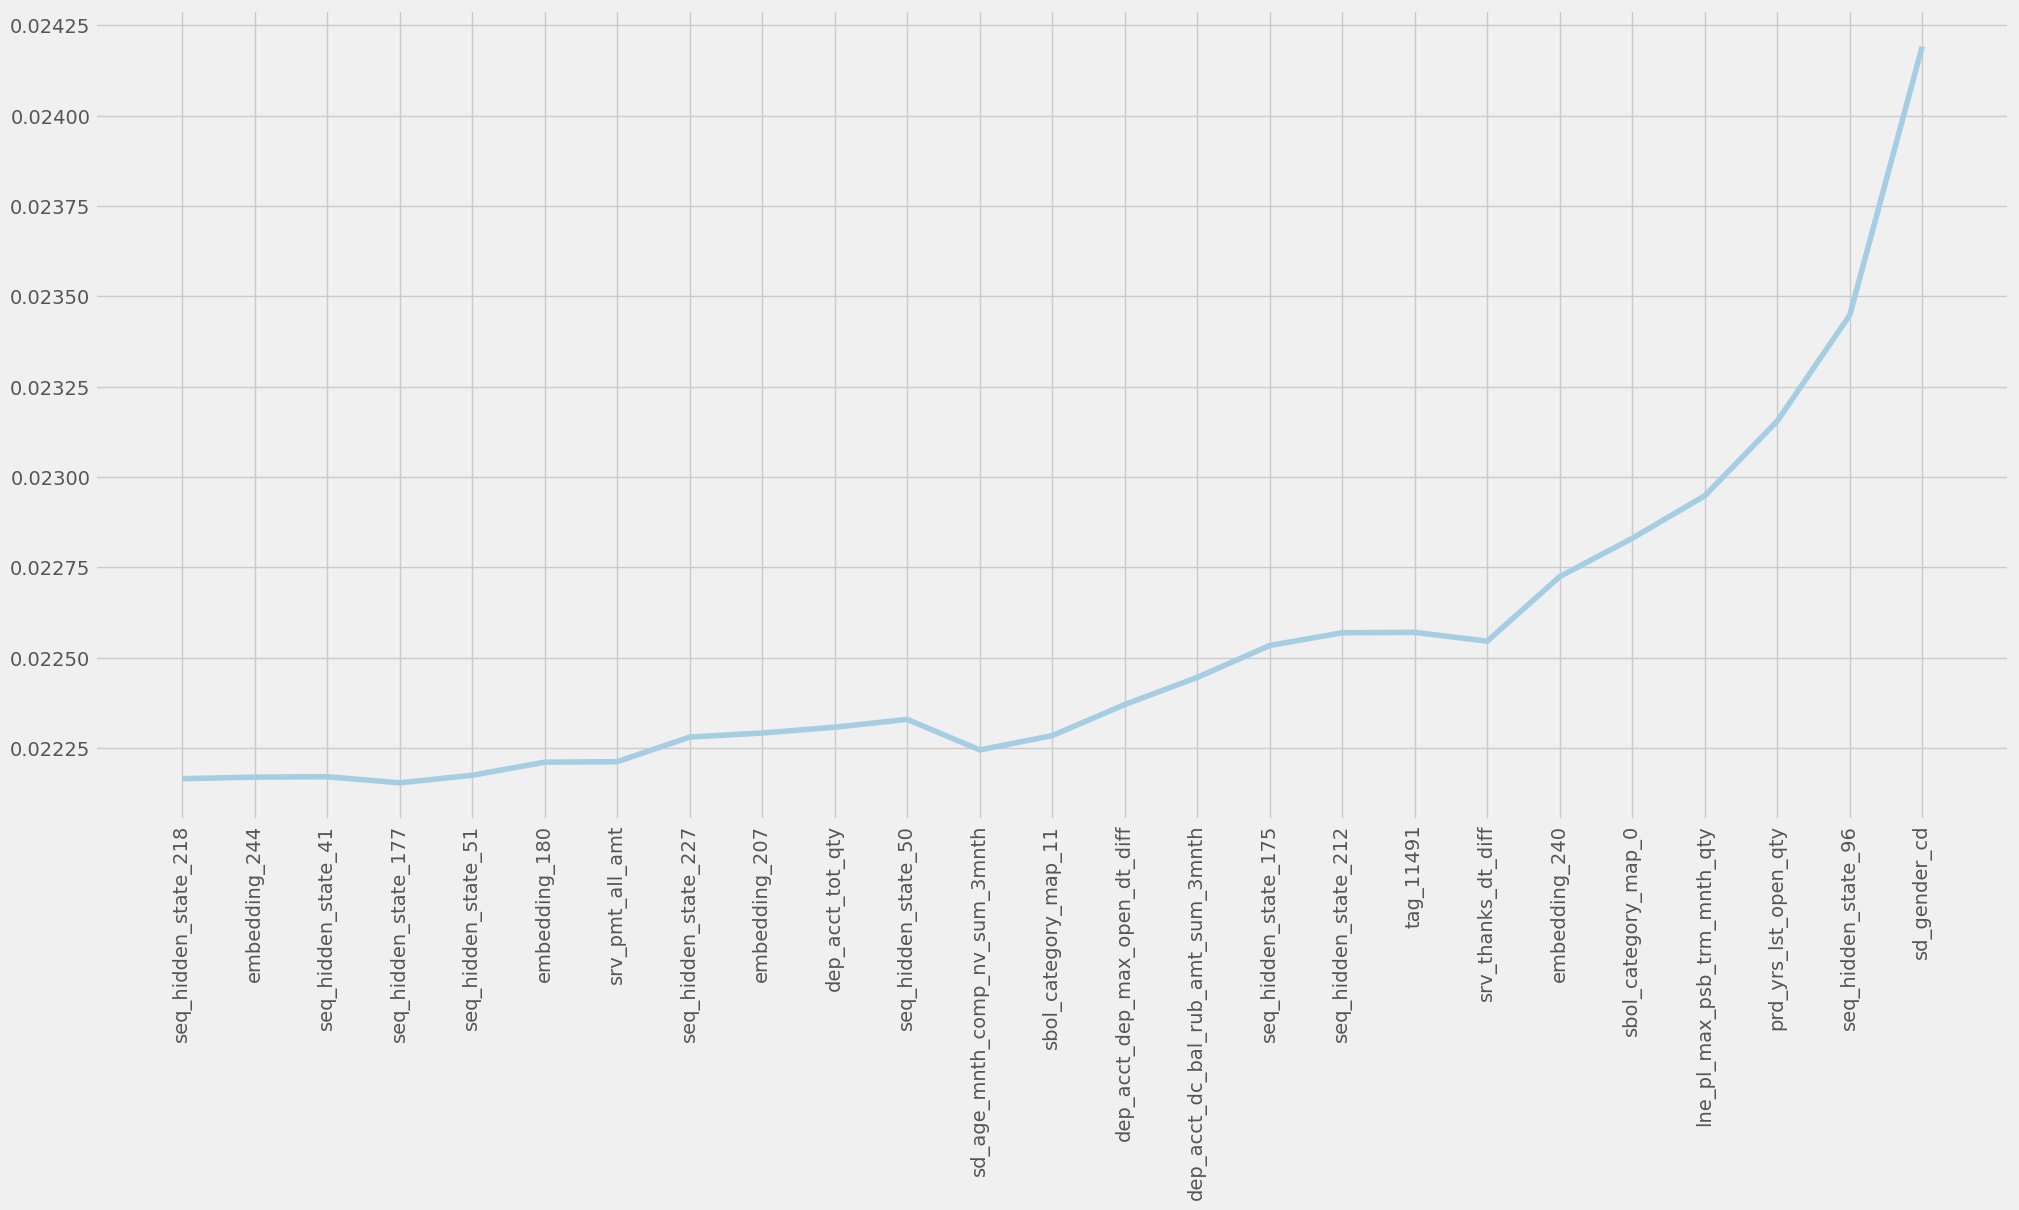

In [7]:
losses = summary_tr['loss_graph']['loss_values'][1:]
plt.figure(figsize=(22, 10))
plt.plot(range(len(losses)), losses)
plt.xticks(range(len(losses)), summary_tr['eliminated_features_names'], rotation=90)

plt.savefig('./img/recursive_selection_tr.png', bbox_inches='tight', dpi=300)

In [76]:
summary_tr['eliminated_features_names'][summary_tr['eliminated_features_names'].index('sd_age_mnth_comp_nv_sum_3mnth'):]

['sd_age_mnth_comp_nv_sum_3mnth',
 'sbol_category_map_11',
 'dep_acct_dep_max_open_dt_diff',
 'dep_acct_dc_bal_rub_amt_sum_3mnth',
 'seq_hidden_state_175',
 'seq_hidden_state_212',
 'tag_11491',
 'srv_thanks_dt_diff',
 'embedding_240',
 'sbol_category_map_0',
 'lne_pl_max_psb_trm_mnth_qty',
 'prd_yrs_lst_open_qty',
 'seq_hidden_state_96',
 'sd_gender_cd']

In [77]:
selected_tr = summary_tr['selected_features_names'] \
+ summary_tr['eliminated_features_names'][summary_tr['eliminated_features_names'].index('sd_age_mnth_comp_nv_sum_3mnth'):]

In [78]:
selected_tr = [f for f in selected_tr if f != 'is_treated']

##### Control

In [8]:
with open('./cache/feature_selection/summary_catboost_c.txt', 'r') as f:
    summary_c = json.load(f)

In [9]:
summary_c['selected_features_names']

['lne_pl_max_psb_trm_mnth_qty']

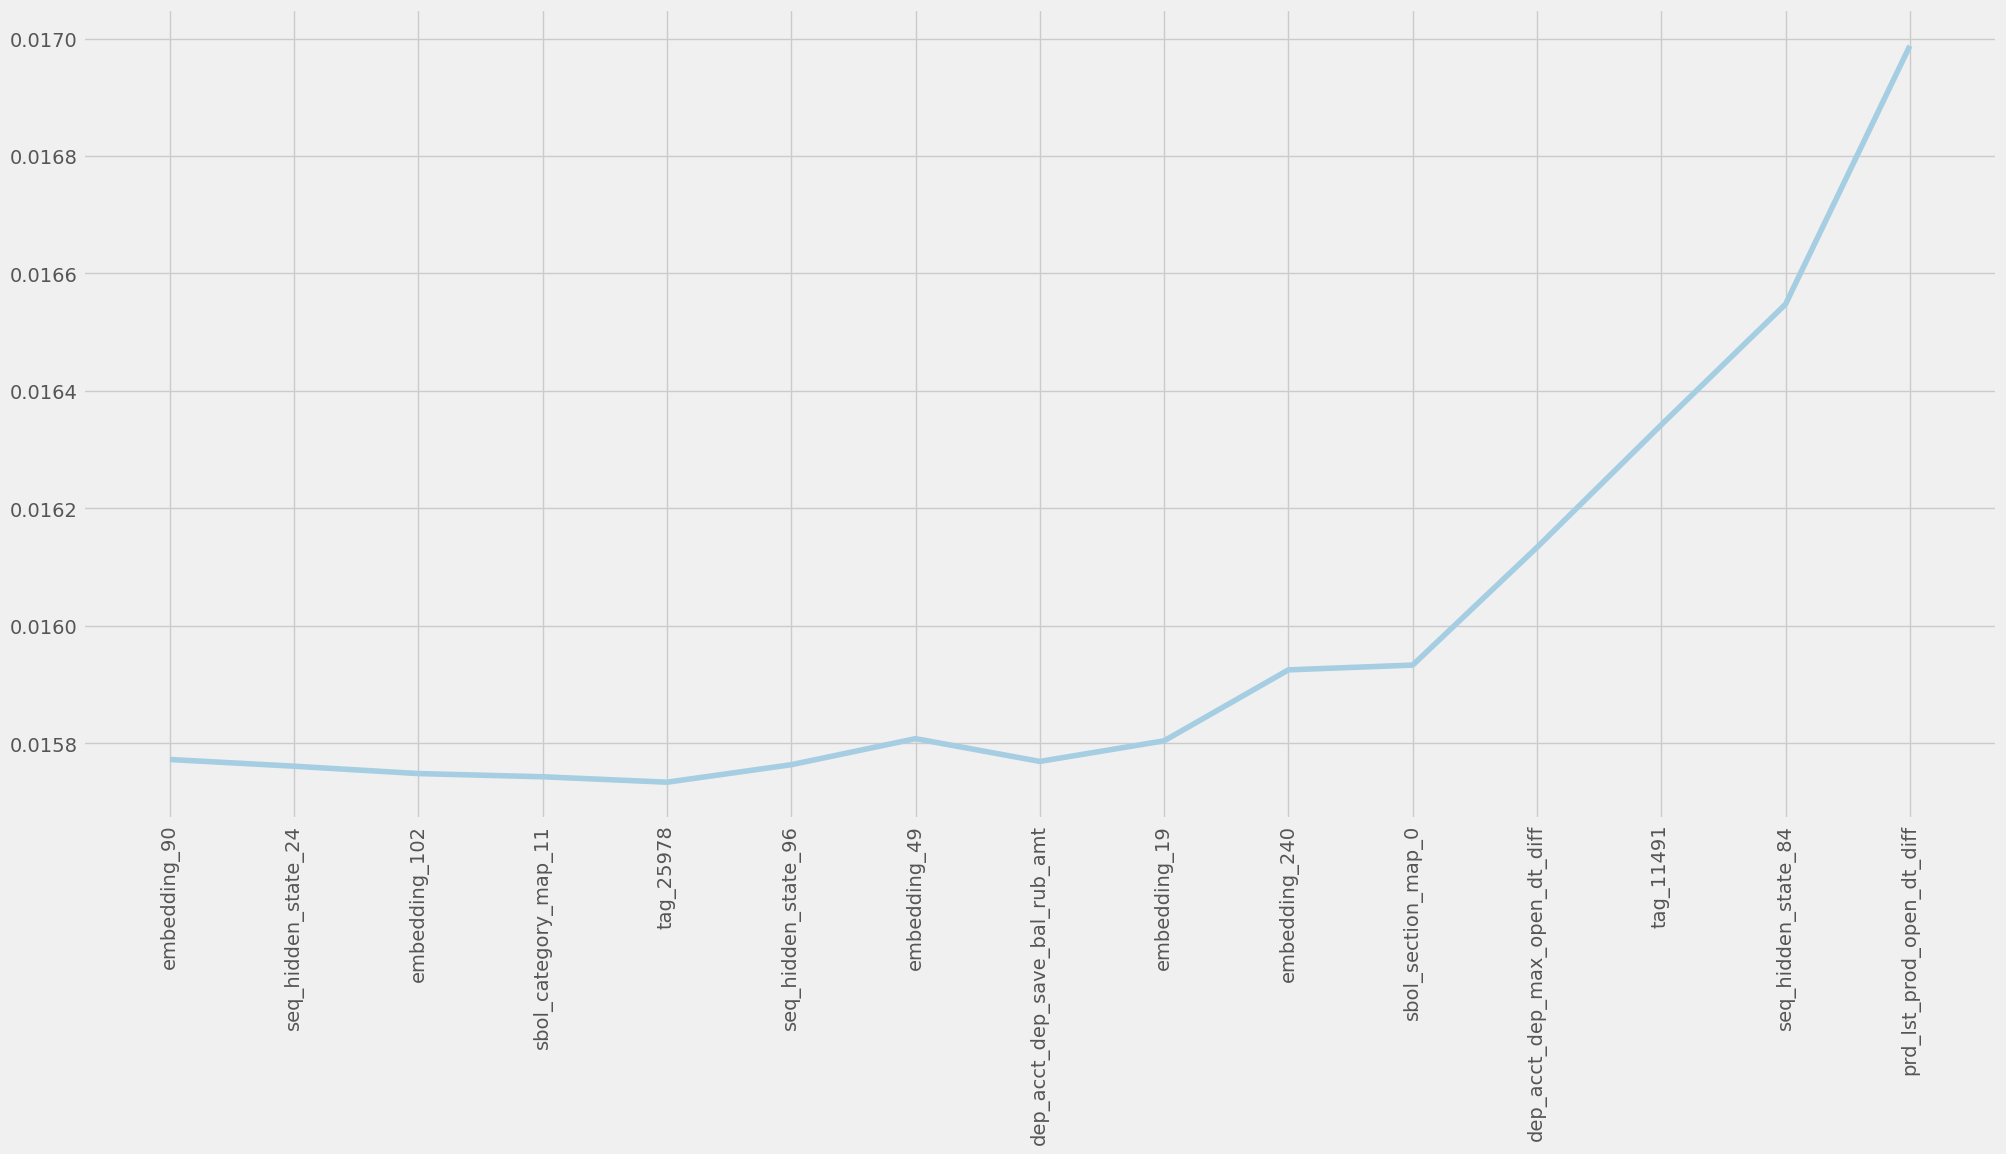

In [10]:
losses = summary_c['loss_graph']['loss_values'][1:]
plt.figure(figsize=(22, 10))
plt.plot(range(len(losses)), losses)
plt.xticks(range(len(losses)), summary_c['eliminated_features_names'], rotation=90)

plt.savefig('./img/recursive_selection_c.png', bbox_inches='tight', dpi=300)

In [82]:
summary_c['eliminated_features_names'][summary_c['eliminated_features_names'].index('dep_acct_dep_save_bal_rub_amt'):]

['dep_acct_dep_save_bal_rub_amt',
 'embedding_19',
 'embedding_240',
 'sbol_section_map_0',
 'dep_acct_dep_max_open_dt_diff',
 'tag_11491',
 'seq_hidden_state_84',
 'prd_lst_prod_open_dt_diff']

In [83]:
selected_c = summary_c['selected_features_names'] \
+ summary_c['eliminated_features_names'][summary_c['eliminated_features_names'].index('dep_acct_dep_save_bal_rub_amt'):]

##### All

In [87]:
print(len(selected_tr), len(selected_c))
selected_all = list(set(selected_tr) | set(selected_c))

joblib.dump(selected_all, './cache/feature_selection/features_all.pkl')

15 9


['./cache/feature_selection/features_all.pkl']

In [88]:
len(selected_all)

19

In [89]:
selected_all

['dep_acct_dc_bal_rub_amt_sum_3mnth',
 'embedding_240',
 'sd_gender_cd',
 'prd_yrs_lst_open_qty',
 'tag_11491',
 'dep_acct_dep_save_bal_rub_amt',
 'seq_hidden_state_84',
 'sbol_category_map_0',
 'dep_acct_dep_max_open_dt_diff',
 'sbol_category_map_11',
 'seq_hidden_state_96',
 'prd_lst_prod_open_dt_diff',
 'sd_age_mnth_comp_nv_sum_3mnth',
 'embedding_19',
 'srv_thanks_dt_diff',
 'seq_hidden_state_212',
 'seq_hidden_state_175',
 'sbol_section_map_0',
 'lne_pl_max_psb_trm_mnth_qty']

# Описание отобранных признаков

In [20]:
selected_all = joblib.load('./cache/feature_selection/features_all.pkl')

In [21]:
megav_desc = pd.read_excel('./cache/feature_description.xlsx', sheet_name='megav')
hashtags_desc = pd.read_excel('./cache/feature_description.xlsx', sheet_name='hashtags')
risk_desc = pd.read_excel('./cache/feature_description.xlsx', sheet_name='risk')

feature_descriptions = pd.concat([megav_desc, hashtags_desc, risk_desc], ignore_index=True)
feature_descriptions['name'] = feature_descriptions['name'].astype('str')

feature_descriptions = pd.concat([feature_descriptions, pd.DataFrame({
    'name': ['seq_hidden_state', 'embedding'],
    'description': ['Эмбеддинг ЦД CDS', 'Эмбеддинг ML360'],
    'tag_chld': [np.nan, np.nan]})], ignore_index=True)

del megav_desc, hashtags_desc, risk_desc

In [22]:
selected_all_df = pd.DataFrame({"name": selected_all})
selected_all_df['join_name'] = selected_all_df['name']
selected_all_df['join_name'] = selected_all_df['join_name'].apply(lambda x: x[:-5] if x.endswith('_diff') else x)
selected_all_df['join_name'] = selected_all_df['join_name'].apply(lambda x: x[4:] if x.startswith('tag_') else x)
selected_all_df['join_name'] = selected_all_df['join_name'].apply(lambda x: x[:-4] if x.endswith('_sum') else x)
selected_all_df['join_name'] = selected_all_df['join_name'].apply(lambda x: x[:9] if x.startswith('embedding_') else x)
selected_all_df['join_name'] = selected_all_df['join_name'].apply(lambda x: x[:x.index('state_')+5] if x.startswith('seq_h') else x)
selected_all_df

,name,join_name
0,dep_acct_dc_bal_rub_amt_sum_3mnth,dep_acct_dc_bal_rub_amt_sum_3mnth
1,embedding_240,embedding
2,sd_gender_cd,sd_gender_cd
3,prd_yrs_lst_open_qty,prd_yrs_lst_open_qty
4,tag_11491,11491
5,dep_acct_dep_save_bal_rub_amt,dep_acct_dep_save_bal_rub_amt
6,seq_hidden_state_84,seq_hidden_state
7,sbol_category_map_0,sbol_category_map_0
8,dep_acct_dep_max_open_dt_diff,dep_acct_dep_max_open_dt
9,sbol_category_map_11,sbol_category_map_11


In [43]:
f_desc = selected_all_df.merge(feature_descriptions.rename(columns={'name': 'join_name'}), on='join_name', how='left')
f_desc.drop('join_name', axis=1, inplace=True)
f_desc.to_excel('./cache/feature_selection/selected_feature_description.xlsx', index=False)

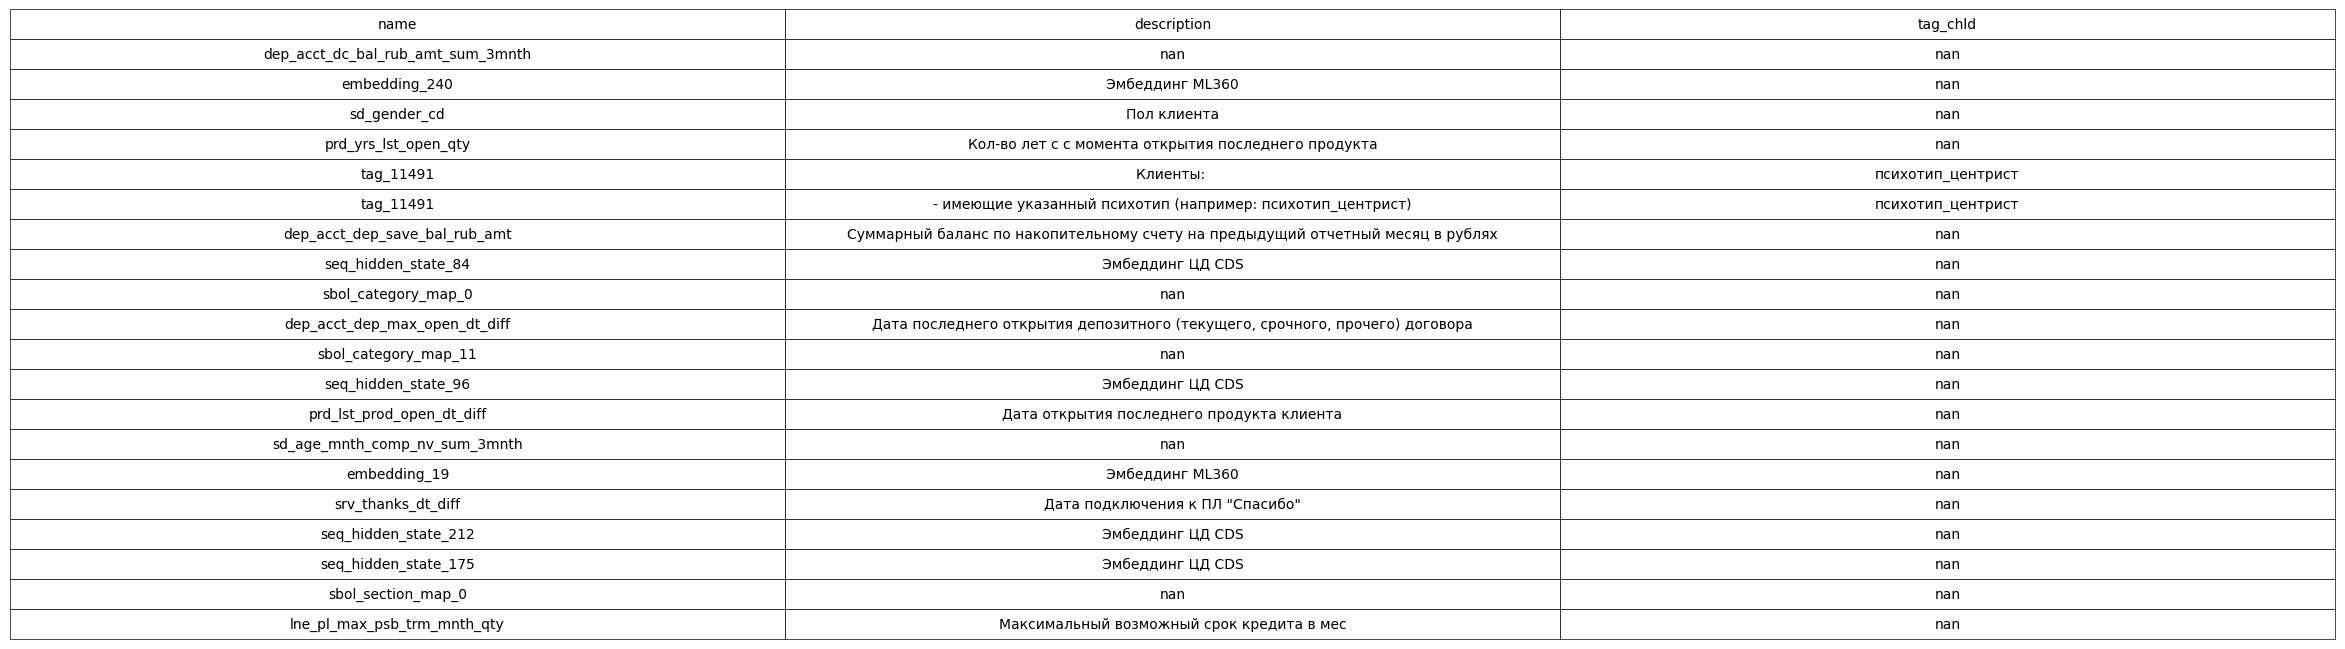

In [28]:
pd.set_option("display.max_colwidth", 1000)

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=f_desc.values, colLabels=f_desc.columns, cellLoc='center', loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(2.5, 1.8)

plt.savefig('./img/feature_selection/feature_description_t.png', bbox_inches='tight', dpi=300)

In [107]:
# если нужно выкинуть какие-то признаки
# selected_all = [f for f in selected_all if f not in ['is_treated', 'crd_lst_agrmnt_osb_cd', 'dep_acct_1st_division_dk']]

In [95]:
len(selected_all)

19

In [96]:
joblib.dump(selected_all, './cache/feature_selection/features_all.pkl')

['./cache/feature_selection/features_all.pkl']

# Из каких источников получены признаки

In [29]:
MEGAFEATURES_TABLENAME = 'srs_bo_push_aggr_features'
HASHTAGS_TABLENAME = 'srs_bo_push_hashtags_features'
TRANSACTION_TABLENAME = 'srs_bo_push_transaction_features'
MEGAFEATURES_PNL_CLTV_TABLENAME = 'srs_bo_push_aggr_pnl_cltv_features'
CDS_TABLENAME = 'srs_bo_push_cds_features'

PL_LAGS_TABLENAME = 'srs_pl_datasets_epk_by_mnth'
CLICKSTREAM_TABLENAME = 'dsg_cs_agg_data_2025'

sources_columns = {
    'Мегавитрина': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{MEGAFEATURES_TABLENAME}").columns,
    'Хэштеги': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{HASHTAGS_TABLENAME}").columns,
    'СБОЛ Кликстрим': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{CLICKSTREAM_TABLENAME}").columns,
    'Эмбеддинги ML360': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{TRANSACTION_TABLENAME}").columns,
    'PnL, CLTV Мегавитрины': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{MEGAFEATURES_PNL_CLTV_TABLENAME}").columns,
    'Лаги по PL': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{PL_LAGS_TABLENAME}").columns,
    'Эмбеддинги ЦД': spark.table(f"arnsdpsbx_t_team_mp_cmpn_ds.{CDS_TABLENAME}").columns,
    'Геоданные': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.ysa_epk_address").columns,
    'Оконные агрегаты мегавитрины': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.src_mv_window_fatures").columns,
    'Фичи ИНН': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.knv_inn_card_trans_aggr").columns,
    'Фичи Маркетплейсов': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.knv_inn_marketplace_aggr").columns,
    'Агрегаты над ВНВ': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.dsg_vnv_data_2025").columns,
    'Агрегаты над ЕВК': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.dsg_evk_data_2025").columns,
    'Фичи СберПрайм': spark.table("arnsdpsbx_t_team_mp_cmpn_ds.dsg_prime_data_2025").columns
}

clear_output()

In [44]:
selected_all_df2 = pd.DataFrame({"name": selected_all})
selected_all_df2['join_name'] = selected_all_df2['name']
selected_all_df2['join_name'] = selected_all_df2['join_name'].apply(lambda x: x[:-5] if x.endswith('_diff') else x)
selected_all_df2['join_name'] = selected_all_df2['join_name'].apply(lambda x: x[:-4] if x.endswith('_sum') else x)

In [50]:
from collections import defaultdict

source = defaultdict(list)
for feature_name, feature in zip(selected_all_df2['name'].values, selected_all_df2['join_name'].values):
    for source_name, cols in sources_columns.items():
        if feature in cols:
            source[feature_name].append(source_name)

In [51]:
set(selected_all) - set(source)

set()

In [52]:
len(source) == len(selected_all)

True

In [53]:
f_desc

,name,description,tag_chld
0,dep_acct_dc_bal_rub_amt_sum_3mnth,NaN,NaN
1,embedding_240,Эмбеддинг ML360,NaN
2,sd_gender_cd,Пол клиента,NaN
3,prd_yrs_lst_open_qty,Кол-во лет с с момента открытия последнего продукта,NaN
4,tag_11491,Клиенты:,психотип_центрист
5,tag_11491,- имеющие указанный психотип (например: психотип_центрист),психотип_центрист
6,dep_acct_dep_save_bal_rub_amt,Суммарный баланс по накопительному счету на предыдущий отчетный месяц в рублях,NaN
7,seq_hidden_state_84,Эмбеддинг ЦД CDS,NaN
8,sbol_category_map_0,NaN,NaN
9,dep_acct_dep_max_open_dt_diff,"Дата последнего открытия депозитного (текущего, срочного, прочего) договора",NaN


In [54]:
f_source = pd.DataFrame(pd.Series(source, name='source')).reset_index(names=['name'])

f_source

,name,source
0,dep_acct_dc_bal_rub_amt_sum_3mnth,[Оконные агрегаты мегавитрины]
1,embedding_240,[Эмбеддинги ML360]
2,sd_gender_cd,[Мегавитрина]
3,prd_yrs_lst_open_qty,[Мегавитрина]
4,tag_11491,[Хэштеги]
5,dep_acct_dep_save_bal_rub_amt,[Мегавитрина]
6,seq_hidden_state_84,[Эмбеддинги ЦД]
7,sbol_category_map_0,[СБОЛ Кликстрим]
8,dep_acct_dep_max_open_dt_diff,[Мегавитрина]
9,sbol_category_map_11,[СБОЛ Кликстрим]


In [55]:
f_source['source'].value_counts()

source
[Мегавитрина]                     7
[Эмбеддинги ЦД]                   4
[СБОЛ Кликстрим]                  3
[Оконные агрегаты мегавитрины]    2
[Эмбеддинги ML360]                2
[Хэштеги]                         1
Name: count, dtype: int64

In [56]:
f_desc = f_desc.merge(f_source, on='name', how='left')
f_desc

,name,description,tag_chld,source
0,dep_acct_dc_bal_rub_amt_sum_3mnth,NaN,NaN,[Оконные агрегаты мегавитрины]
1,embedding_240,Эмбеддинг ML360,NaN,[Эмбеддинги ML360]
2,sd_gender_cd,Пол клиента,NaN,[Мегавитрина]
3,prd_yrs_lst_open_qty,Кол-во лет с с момента открытия последнего продукта,NaN,[Мегавитрина]
4,tag_11491,Клиенты:,психотип_центрист,[Хэштеги]
5,tag_11491,- имеющие указанный психотип (например: психотип_центрист),психотип_центрист,[Хэштеги]
6,dep_acct_dep_save_bal_rub_amt,Суммарный баланс по накопительному счету на предыдущий отчетный месяц в рублях,NaN,[Мегавитрина]
7,seq_hidden_state_84,Эмбеддинг ЦД CDS,NaN,[Эмбеддинги ЦД]
8,sbol_category_map_0,NaN,NaN,[СБОЛ Кликстрим]
9,dep_acct_dep_max_open_dt_diff,"Дата последнего открытия депозитного (текущего, срочного, прочего) договора",NaN,[Мегавитрина]


In [57]:
f_desc.to_excel('./cache/feature_selection/selected_feature_description_extended.xlsx', index=False)